In [3]:
import os
print(os.getcwd())

C:\Users\HOME


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import erfc
import matplotlib.pyplot as plt

# Masa: Soles (Msun), Tiempo: Millones de años (Myr), Distancia: Parsecs (pc)
# Velocidad: pc/Myr (~0.97 km/s)

G = 4.498e-3            # Constante gravitacional en pc^3 / (Msun * Myr^2)
ESN = 10**51 / 1.989e33 * (1.02e-6)**2 # E_sn convertida a (Msun * pc^2 / Myr^2)
KB_CODE = 0.129         # Constante de Boltzmann escalada para T en Kelvin

class ISM_SelfRegulation:
    def __init__(self):
        # Parámetros iniciales
        self.M_gas_0 = 1e8     # M_sun
        self.R_cloud = 1000      # pc
        self.vol = (4/3) * np.pi * self.R_cloud**3
        self.cs_thermal = 0.2   # pc/Myr (~0.2 km/s para gas frío)
        self.eta_sn = 0.01      # Supernovas por cada M_sun formada
        
    def get_f_coll(self, rho_avg, sigma_v, cs):
        """Calcula la fracción de masa que colapsa según la log-normal"""
        # Mach efectivo (turbulento)
        mach = sigma_v / cs
        sigma_s = np.sqrt(np.log(1 + 0.25 * mach**2))
        
        # Densidad crítica de Bonnor-Ebert (simplificada)
        # rho_crit ~ cs^2 / (G * R^2) - Si rho_avg es muy baja, no hay colapso
        rho_be = 15 * ( cs**2 + 3 * sigma_v**2 )  / (G * self.R_cloud**2) 
        # print(rho_be, rho_avg)
        
        s_crit = np.log(max(rho_be / rho_avg, 1.01))
        # Fracción de masa con rho > rho_be
        f = 0.5 * erfc((s_crit - sigma_s**2 / 2) / (np.sqrt(2) * sigma_s))
        return max(f, 1e-6) # Forzamos un mínimo para ver evolución

    def system_equations(self, t, y):
        Mg, Ek, Et = y # Masa gas, E_cinética, E_térmica
        
        if Mg <= 10: return [0, 0, 0] # Se acabó el gas
        
        rho = Mg / self.vol
        t_ff = np.sqrt(3 * np.pi / (32 * G * rho))
        
        # 1. Velocidades y Mach
        sigma_v = np.sqrt(max(2 * Ek / Mg, 1e-4))
        
        # 2. Star Formation Rate (SFR)
        f_coll = self.get_f_coll(rho, sigma_v, self.cs_thermal)
        sfr = (f_coll * Mg) / t_ff
        
        # 3. Feedback de Supernovas
        # Inyectamos energía según la SFR
        edot_sn = sfr * self.eta_sn * ESN
        
        # 4. Enfriamiento ( Cooling )
        # t_cool proporcional a la densidad: más denso = más choques = más rápido se enfría
        t_cool = 5.0 * (1e-2 / rho) 
        edot_cool = Et / t_cool
        
        # Ecuaciones diferenciales
        dMg_dt = -sfr
        dEk_dt = 0.8 * edot_sn #- (Ek / t_ff) # 80% va a turbulencia, se disipa en t_ff
        dEt_dt = 0.2 * edot_sn - edot_cool   # 20% va a calor
        
        return [dMg_dt, dEk_dt, dEt_dt]

# --- Ejecución ---
model = ISM_SelfRegulation()
# Inicializamos con algo de energía para que el Mach no sea 0
y0 = [model.M_gas_0, 1e4, 1e3] 
t_span = (0, 500) # 500 Myr

sol = solve_ivp(model.system_equations, t_span, y0, method='RK45', rtol=1e-6)

# --- Gráficos ---
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Tiempo (Myr)')
ax1.set_ylabel('Masa de Gas ($M_\odot$)', color='blue')
#ax1.plot(sol.t, np.sqrt(2*sol.y[1]/sol.y[0]), color='blue', linewidth=2, label='Masa Gas')
ax1.plot(sol.t, sol.y[0], color='blue', linewidth=2, label='Masa Gas')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Energía Cinética (Unidades Código)', color='red')
ax2.plot(sol.t, sol.y[1], color='red', linestyle='--', label='Turbulencia (Ek)')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Evolución del ISM con Autorregulación por Supernovas")
plt.show()

# Version corregida


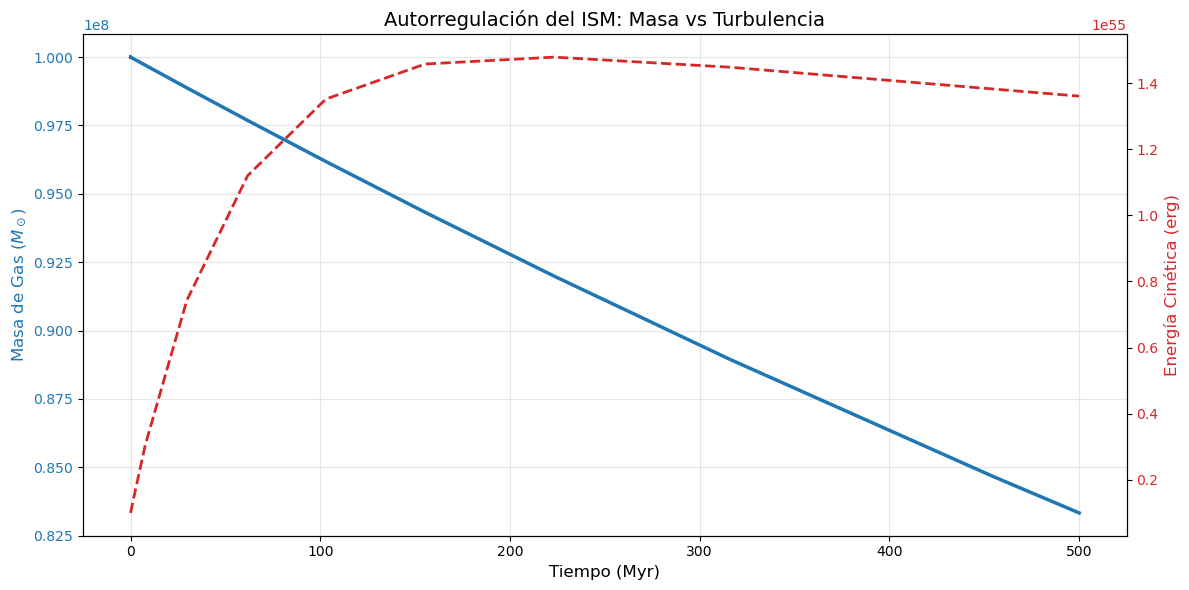

In [10]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import G, m_p, k_B

class ISM_SelfRegulation:
    def __init__(self):
        # --- 1. Definición de Parámetros (Con Unidades) ---
        m_gas_init = 1e8 * u.Msun
        r_cloud = 1000 * u.pc
        self.vol_cgs = ((4/3) * np.pi * r_cloud**3).to(u.cm**3).value
        
        # Parámetros tc 
        self.a = -0.7               
        lambda_a = 2e-23 * u.erg * u.cm**3 / u.s 
        t_a = 1e6 * u.K           
        self.chi = 1.0               
        self.mu = 0.6                
        e0_sn = 1e51 * u.erg    

        # --- 2. Pre-cálculo de Constantes (CGS) ---
        # Lo inclui pues me fallaba al calcular tc con astro units
        self.G_cgs = G.cgs.value
        self.mp_cgs = m_p.cgs.value
        self.kB_cgs = k_B.cgs.value
        self.E0_cgs = e0_sn.cgs.value
        self.Lambda_cgs = lambda_a.cgs.value
        self.Ta_cgs = t_a.cgs.value
        
        self.sec_to_Myr = u.s.to(u.Myr)
        self.g_to_Msun = u.g.to(u.Msun)
        self.Msun_to_g = u.Msun.to(u.g)

        # y0 = [Masa (g), E_cinetica (erg), E_termica (erg)]
        self.y0 = [m_gas_init.to(u.g).value, 1e54, 1e53]

    def get_physics(self, Mg, Ek, Et):
        rho = Mg / self.vol_cgs
        n0 = rho / (self.mu * self.mp_cgs)
        t_ff = np.sqrt(3 * np.pi / (32 * self.G_cgs * rho))
        
        # Fórmula de la imagen
        term1 = (81 * (1 - self.a) * self.mp_cgs) / (1600 * n0 * self.Lambda_cgs)
        term2 = ((9 * self.mp_cgs) / (80 * self.kB_cgs * self.Ta_cgs))**(-self.a)
        term3 = ((16 * self.chi * self.E0_cgs) / (375 * n0))**( (2/5)*(1 - self.a) )
        
        rhs = term1 * term2 * term3
        t_c = rhs**(5 / (11 - 6 * self.a))
        return t_ff, t_c

    def system_equations(self, t, y):
        Mg, Ek, Et = y
        if Mg <= 1e33: return [0, 0, 0] 

        t_ff, t_c = self.get_physics(Mg, Ek, Et)
        sfr = 0.02 * Mg / t_ff # Por que el 0.02 ???
        eta_g = 0.01 / self.Msun_to_g
        edot_sn = sfr * eta_g * self.E0_cgs
        
        dMg_dt = -sfr
        dEk_dt = 0.8 * edot_sn - (Ek / t_ff) # Inyección vs Disipación
        dEt_dt = 0.2 * edot_sn - (Et / t_c)  # Inyección vs Enfriamiento imagen
        
        return [dMg_dt, dEk_dt, dEt_dt]

# --- Ejecución ---
sim = ISM_SelfRegulation()
t_end_sec = (500 * u.Myr).to(u.s).value
sol = solve_ivp(sim.system_equations, [0, t_end_sec], sim.y0, method='Radau')

# --- Preparación de datos para graficar ---
t_myr = (sol.t * u.s).to(u.Myr).value
m_msun = (sol.y[0] * u.g).to(u.Msun).value
ek_erg = sol.y[1]

# --- Gráfico Dual ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: Masa
ax1.plot(t_myr, m_msun, color='tab:blue', lw=2.5, label='Masa de Gas')
ax1.set_xlabel('Tiempo (Myr)', fontsize=12)
ax1.set_ylabel('Masa de Gas ($M_\odot$)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Eje derecho: Energía Cinética
ax2 = ax1.twinx()
ax2.plot(t_myr, ek_erg, color='tab:red', lw=2, ls='--', label='E. Cinética (Turbulencia)')
ax2.set_ylabel('Energía Cinética (erg)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Autorregulación del ISM: Masa vs Turbulencia', fontsize=14)
fig.tight_layout()
plt.show()

Corregido


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import G, m_p, k_B

class ISM_SelfRegulation:
    def __init__(self):
        # --- 1. Definición de Parámetros (Con Unidades) ---
        m_gas_init = 1e8 * u.Msun
        m_stars_init = 0 * u.Msun
        velocity_init = 10 * u.km/u.s
        temperature_init = 1e4 * u.K
        r_cloud = 1000 * u.pc
        self.volume = (4/3) * np.pi * r_cloud**3
        
        
        # Parámetros cooling_time 
        self.cooling_exponent = -0.7  # Tesis de Mario ( pag 19)              
        self.reference_cooling = 2e-23 * u.erg * u.cm**3 / u.s 
        self.reference_temperature = 1e6 * u.K           
        self.chi = 1.0               
        self.molecular_weight = 0.6                
        self.supernovae_energy = 1e51 * u.erg    


        # y0 = [Masa de gas(g), Masa de estrellas, E_total (erg)]
        # print(m_gas_init, m_stars_init ,  m_gas_init * velocity_init**2 , m_gas_init* k_B * temperature_init/m_p )
        self.initial_state = [m_gas_init.to_value(u.Msun), m_stars_init.to_value(u.Msun),  (m_gas_init * velocity_init**2 / 2 + m_gas_init* k_B * temperature_init/m_p).to_value(u.erg)] 

    def get_physics(self, state):
        gas_mass = state[0] * u.Msun
        star_mass = state[1] * u.Msun
        energy = state[2] * u.erg
        rho_gas = gas_mass  / self.volume
        number_density = rho_gas / self.molecular_weight 
        total_density = (gas_mass + star_mass) / self.volume
        free_fall_time = np.sqrt(3 * np.pi / (32 * G * total_density))
        
        # Fórmula de la tesis de Mario (pag 19)
        term1 = (81 * (1 - self.cooling_exponent) ) / (1600 * number_density * self.reference_cooling)
        term2 = ((9 * m_p) / (80 * k_B * self.reference_temperature))**(-self.cooling_exponent)
        term3 = ((16 * self.chi * self.supernovae_energy) / (375 * number_density))**( (2/5)*(1 - self.cooling_exponent) )
        
        rhs = term1 * term2 * term3
        cooling_time = rhs**(5 / (11 - 6 * self.cooling_exponent))
        return free_fall_time, cooling_time

    def system_equations(self, t, state):
        gas_mass = state[0] * u.Msun
        star_mass = state[1] * u.Msun
        energy = state[2] * u.erg
        # if Mg <= 1e33: return [0, 0, 0] 

        free_fall_time, cooling_time = self.get_physics(state)
        star_formation_rate = 0.02 * gas_mass / free_fall_time # Por que el 0.02 ???
        number_supernovae = 0.01 / u.Msun
        edot_sn = star_formation_rate * number_supernovae * self.supernovae_energy
        
        dgas_dt = -star_formation_rate
        dstars_dt = star_formation_rate 
        # dEk_dt = 0.8 * edot_sn - (Ek / t_ff) # Inyección vs Disipación
        # dEt_dt = 0.2 * edot_sn - (Et / t_c)  # Inyección vs Enfriamiento imagen
        dE_dt = -energy / cooling_time
        
        
        return [dgas_dt.to_value(u.Msun/u.Myr), dstars_dt.to_value(u.Msun/u.Myr), dE_dt.to_value(u.erg/u.Myr)]

# --- Ejecución ---
sim = ISM_SelfRegulation()
t_end = 500 * u.Myr
t_initial = 1 * u.Myr
sol = solve_ivp(sim.system_equations, [t_initial.to_value(u.Myr), t_end.to_value(u.Myr)], sim.initial_state, method='Radau')

UnitConversionError: 'erg(21/19) cm(75/76) solMass(21/38) J(35/152) / (kg(35/152) s(25/76) pc(63/38))' and 'erg / Myr' (power/radiant flux) are not convertible

In [ ]:
# --- Preparación de datos para graficar ---
t_myr = (sol.t * u.s).to(u.Myr).value
m_msun = (sol.y[0] * u.g).to(u.Msun).value
ek_erg = sol.y[1]

# --- Gráfico Dual ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eje izquierdo: Masa
ax1.plot(t_myr, m_msun, color='tab:blue', lw=2.5, label='Masa de Gas')
ax1.set_xlabel('Tiempo (Myr)', fontsize=12)
ax1.set_ylabel('Masa de Gas ($M_\odot$)', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Eje derecho: Energía Cinética
ax2 = ax1.twinx()
ax2.plot(t_myr, ek_erg, color='tab:red', lw=2, ls='--', label='E. Cinética (Turbulencia)')
ax2.set_ylabel('Energía Cinética (erg)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Autorregulación del ISM: Masa vs Turbulencia', fontsize=14)
fig.tight_layout()
plt.show()

TypeError: only dimensionless scalar quantities can be converted to Python scalars